In [25]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.uncertainty import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'adni'
analysis_name = 'mci_ad_conversion'
outcome_name = 'label_bl_36m'
build_ensemble_csv(analysis_name, outcome_name, index_col=['subject_id','month'])


all_patients = pd.read_csv(f'../data/{dataset}/adni_baseline_only_36m.csv')



# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.set_index(['subject_id', 'month'], inplace=True)



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats.index)


all_patients.set_index(['subject_id', 'month'], inplace=True)


actual_outcomes = patients_stats['label'].values
mean_probs = patients_stats['mu'].values

Successfully aggregated 9450 predictions across 314 unique patients.


In [26]:
best_tau = 0.54

In [27]:
# Compute uncertainties for the non-active patients at baseline
from scipy.stats import pointbiserialr

tau = best_tau  # This is the threshold we want to test
uncertainty_metrics, tau = compute_uncertainties(probs_raw_df, patients_stats, tau=tau)
predictions = (patients_stats['mu'] >= tau).astype(int)

# Compute error indicator
is_error = (predictions != actual_outcomes).astype(int)

# Test each metric
results = []

for name, metric in uncertainty_metrics.items():
    # For metrics where LOW = uncertain, flip the sign
    if name in ['Margin', 'Distance_to_tau']:
        metric_for_corr = -metric  # Higher values = more uncertain
    else:
        metric_for_corr = metric
    
    # Compute correlation
    r, p_value = pointbiserialr(is_error, metric_for_corr)
    
    results.append({
        'Metric': name,
        'Correlation': r,
        'P-value': p_value,
        'Significant': p_value < 0.05
    })
    
    print(f"{name:25s} | r = {r:6.3f} | p = {p_value:.4f} | {'✓' if p_value < 0.05 else '✗'}")

# Sort by absolute correlation
results_df = pd.DataFrame(results)
results_df['Abs_Correlation'] = results_df['Correlation'].abs()
results_df = results_df.sort_values('Abs_Correlation', ascending=False)

print("\n=== RANKED BY PREDICTIVE POWER ===")
print(results_df.to_string(index=False))



H_total                   | r =  0.377 | p = 0.0000 | ✓
Margin                    | r =  0.387 | p = 0.0000 | ✓
Inverse_Margin            | r =  0.232 | p = 0.0000 | ✓
Ensemble_Variance         | r =  0.337 | p = 0.0000 | ✓
Ensemble_Std              | r =  0.365 | p = 0.0000 | ✓
H_tau_symmetric           | r =  0.379 | p = 0.0000 | ✓
H_tau_imbalanced          | r =  0.194 | p = 0.0006 | ✓
Var_over_margin           | r =  0.234 | p = 0.0000 | ✓
Distance_to_tau           | r =  0.387 | p = 0.0000 | ✓

=== RANKED BY PREDICTIVE POWER ===
           Metric  Correlation      P-value  Significant  Abs_Correlation
           Margin     0.386610 1.234540e-12         True         0.386610
  Distance_to_tau     0.386610 1.234540e-12         True         0.386610
  H_tau_symmetric     0.379043 3.627876e-12         True         0.379043
          H_total     0.376924 4.882600e-12         True         0.376924
     Ensemble_Std     0.364692 2.599755e-11         True         0.364692
Ensemble_Varianc

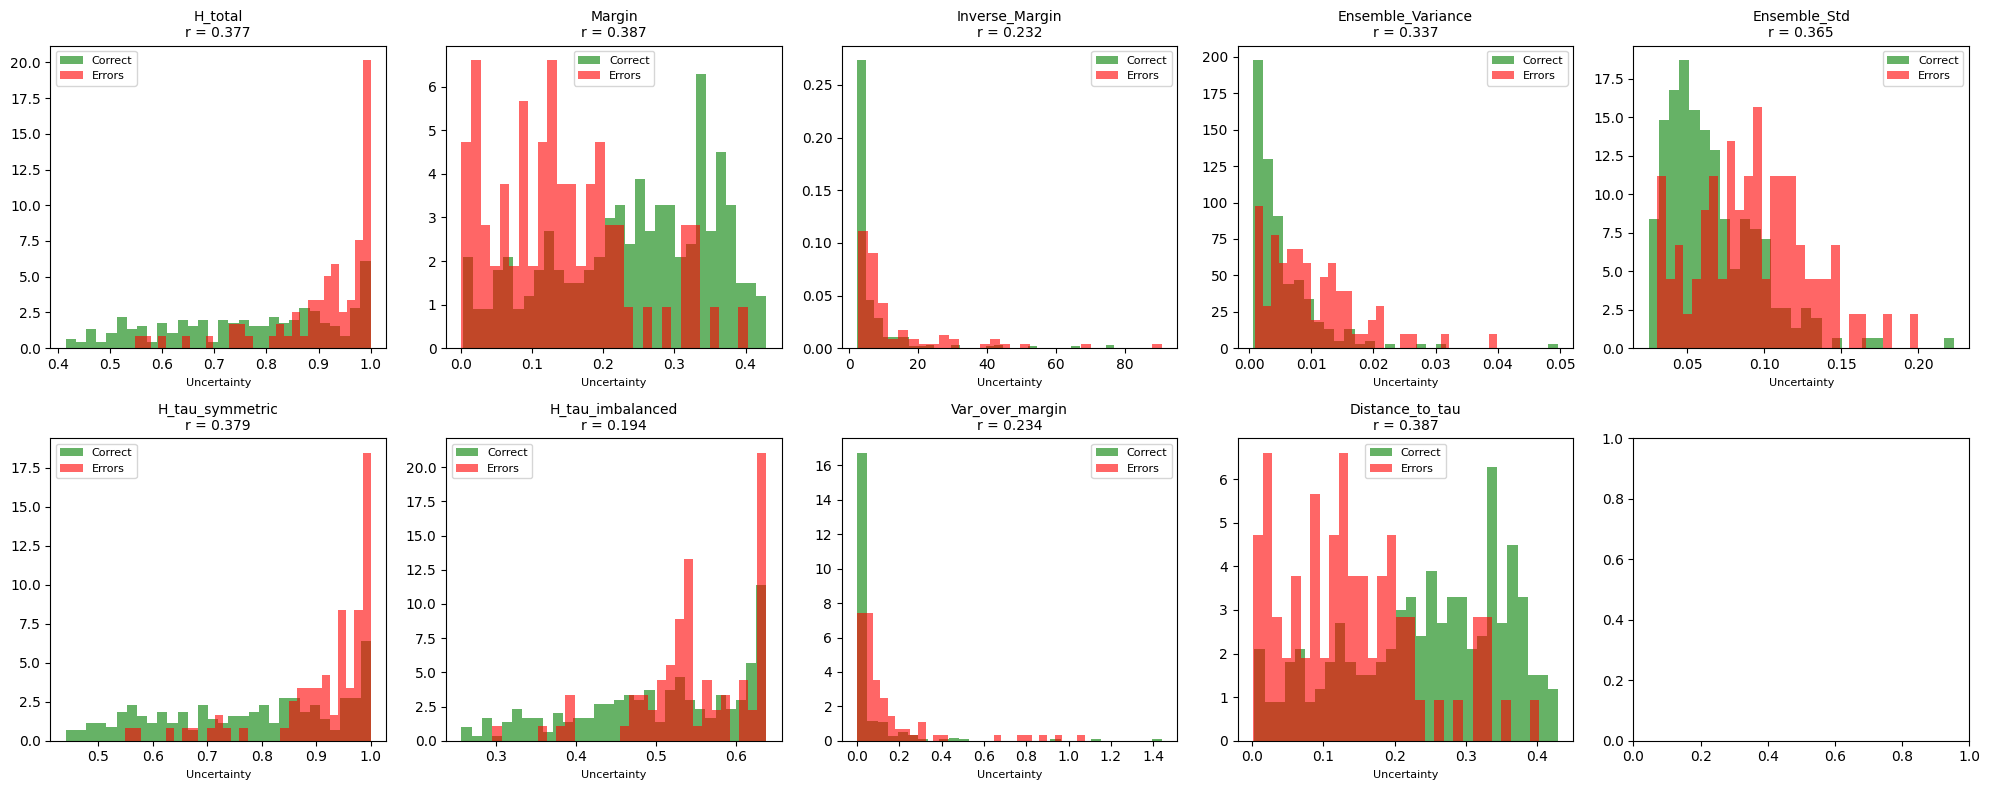

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (name, metric) in enumerate(uncertainty_metrics.items()):
    ax = axes[idx]
    
    # Split by error status
    correct = metric[is_error == 0]
    errors = metric[is_error == 1]
    
    # Plot distributions
    ax.hist(correct, bins=30, alpha=0.6, label='Correct', density=True, color='green')
    ax.hist(errors, bins=30, alpha=0.6, label='Errors', density=True, color='red')
    
    # Get correlation
    r = results_df[results_df['Metric'] == name]['Correlation'].values[0]
    
    ax.set_title(f"{name}\nr = {r:.3f}", fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Uncertainty', fontsize=8)
    
plt.tight_layout()
plt.show()


In [31]:
uncertainty_metrics.keys()

dict_keys(['H_total', 'Margin', 'Inverse_Margin', 'Ensemble_Variance', 'Ensemble_Std', 'H_tau_symmetric', 'H_tau_imbalanced', 'Var_over_margin', 'Distance_to_tau'])

In [33]:
all_results

{'H_total':     Reject_Rate  Sensitivity  Specificity     AUPRC  Retained_N
 0      0.000000     0.752941     0.743056  0.870549         314
 1      0.025862     0.775758     0.735714  0.874842         305
 2      0.051724     0.795031     0.727941  0.878945         297
 3      0.077586     0.810127     0.717557  0.883573         289
 4      0.103448     0.834437     0.715385  0.887469         281
 5      0.129310     0.842466     0.716535  0.891903         273
 6      0.155172     0.846154     0.737705  0.896389         265
 7      0.181034     0.845070     0.730435  0.901283         257
 8      0.206897     0.852941     0.734513  0.905914         249
 9      0.232759     0.863636     0.743119  0.910714         241
 10     0.258621     0.882812     0.761905  0.915397         233
 11     0.284483     0.899160     0.761905  0.921312         224
 12     0.310345     0.905983     0.787879  0.925331         216
 13     0.336207     0.911504     0.810526  0.929228         208
 14     0.3620

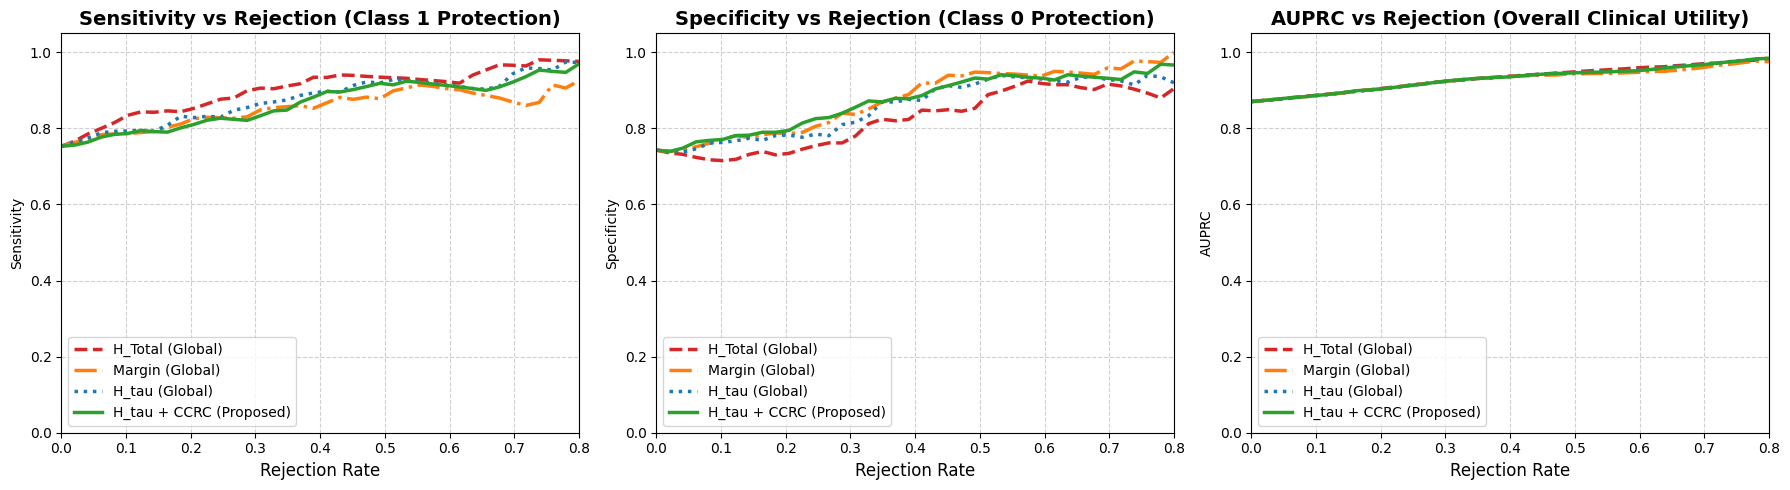

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix
import warnings
warnings.filterwarnings('ignore') # Suppress warnings when classes are completely erased

def compute_ablation_metrics(y_true, y_prob, tau, metric_scores, reject_rates, mode='global'):
    """
    Simulates triage using either Global Rejection or Class-Conditioned Rejection (CCRC).
    Assumes metric_scores are aligned so that HIGHER values = MORE UNCERTAIN.
    """
    results = []
    
    # Get baseline predictions based on the optimal threshold
    base_preds = (y_prob >= tau).astype(int)
    
    for rate in reject_rates:
        if rate >= 1.0: 
            continue # Cannot evaluate if 100% of patients are rejected
            
        if mode == 'global':
            # --- GLOBAL REJECTION ---
            # Find the global cutoff (e.g. for 20% rejection, find the 80th percentile)
            # Keep patients strictly below this uncertainty cutoff
            cutoff_val = np.percentile(metric_scores, 100 * (1 - rate))
            keep_mask = metric_scores <= cutoff_val
            
        elif mode == 'ccrc':
            # --- CLASS-CONDITIONED REJECTION (CCRC) ---
            # Evaluate uncertainty ordinally within the predicted trajectories
            keep_mask = np.zeros_like(y_true, dtype=bool)
            
            for c in [0, 1]:
                class_idx = (base_preds == c)
                if np.sum(class_idx) > 0:
                    class_scores = metric_scores[class_idx]
                    # Find the cutoff strictly for this specific class
                    class_cutoff = np.percentile(class_scores, 100 * (1 - rate))
                    # Keep patients in this class who are below their own uncertainty cutoff
                    keep_mask[class_idx] = metric_scores[class_idx] <= class_cutoff
        
        # Filter the cohort
        y_true_kept = y_true[keep_mask]
        y_prob_kept = y_prob[keep_mask]
        preds_kept = base_preds[keep_mask]
        
        # --- CALCULATE CLINICAL METRICS ON RETAINED PATIENTS ---
        if len(np.unique(y_true_kept)) < 2:
            # If a class is completely erased, metrics collapse
            sens, spec, auprc = 0.0, 0.0, 0.0
        else:
            tn, fp, fn, tp = confusion_matrix(y_true_kept, preds_kept, labels=[0, 1]).ravel()
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            
            precision, recall, _ = precision_recall_curve(y_true_kept, y_prob_kept)
            auprc = auc(recall, precision)
            
        results.append({
            'Reject_Rate': rate,
            'Sensitivity': sens,
            'Specificity': spec,
            'AUPRC': auprc
        })
        
    return pd.DataFrame(results)

# ==========================================
# EXECUTE THE 4-WAY ABLATION STUDY
# ==========================================
# (Assuming actual_outcomes, mean_probs, best_tau, and your metrics dictionary are already loaded)

# Sweep from 0% to 80% rejection to capture the crashes
reject_rates = np.linspace(0, 0.80, 40) 

# Ensure metrics are oriented so HIGH = Uncertain
h_total_scores = uncertainty_metrics['H_total']
h_tau_scores = uncertainty_metrics['H_tau_symmetric']
margin_scores = -np.abs(mean_probs - best_tau) # Pure Margin inverted: small distance -> high uncertainty

# 1. Standard AI (H_Total Global)
df_htotal_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_total_scores, reject_rates, mode='global'
)

# 2. Pure Margin Global (The Naive Fix)
df_margin_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, margin_scores, reject_rates, mode='global'
)

# 3. Piecewise Entropy Global (The Theoretical Fix)
df_htau_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_tau_scores, reject_rates, mode='global'
)

# 4. Piecewise Entropy + CCRC (The SOTA Pipeline)
df_htau_ccrc = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_tau_scores, reject_rates, mode='ccrc'
)

# ==========================================
# VISUALIZE THE RESULTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('H_Total (Global)', df_htotal_global, '#d62728', '--'),   # Red, dashed (Standard AI Failure)
    ('Margin (Global)', df_margin_global, '#ff7f0e', '-.'),    # Orange, dash-dot (Runway Failure)
    ('H_tau (Global)', df_htau_global, '#1f77b4', ':'),        # Blue, dotted (Density Failure)
    ('H_tau + CCRC (Proposed)', df_htau_ccrc, '#2ca02c', '-')  # Green, solid (The Fix)
]

for name, df, color, linestyle in configs:
    axes[0].plot(df['Reject_Rate'], df['Sensitivity'], label=name, color=color, linestyle=linestyle, linewidth=2.5)
    axes[1].plot(df['Reject_Rate'], df['Specificity'], label=name, color=color, linestyle=linestyle, linewidth=2.5)
    axes[2].plot(df['Reject_Rate'], df['AUPRC'], label=name, color=color, linestyle=linestyle, linewidth=2.5)

# Formatting Panel 1: Sensitivity (Tracks Minority-Class Erasure)
axes[0].set_title("Sensitivity vs Rejection (Class 1 Protection)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Sensitivity")

# Formatting Panel 2: Specificity (Tracks Majority-Class Erasure)
axes[1].set_title("Specificity vs Rejection (Class 0 Protection)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Specificity")

# Formatting Panel 3: AUPRC (Overall Clinical Trajectory)
axes[2].set_title("AUPRC vs Rejection (Overall Clinical Utility)", fontsize=14, fontweight='bold')
axes[2].set_ylabel("AUPRC")

# Universal Formatting
for ax in axes:
    ax.set_xlabel("Rejection Rate", fontsize=12)
    ax.set_xlim([0, 0.80])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=10, loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()